In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [10]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [11]:
df = pd.read_csv("citrus.csv")
df.head()

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [13]:
df.describe()

,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


In [14]:
df['name'].value_counts()

,count
name,
orange,5000
grapefruit,5000


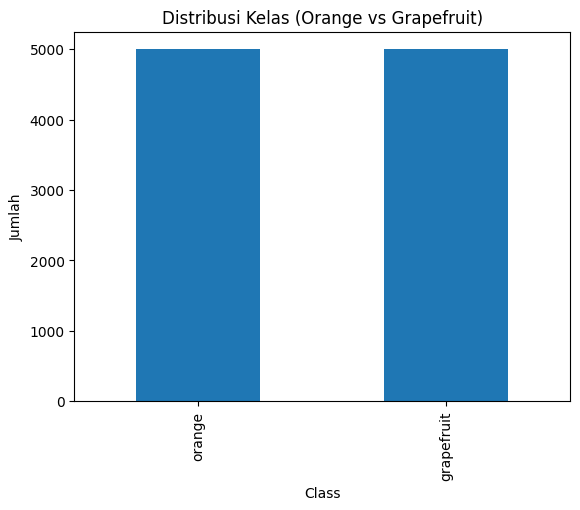

In [15]:
df['name'].value_counts().plot(kind='bar')
plt.title("Distribusi Kelas (Orange vs Grapefruit)")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

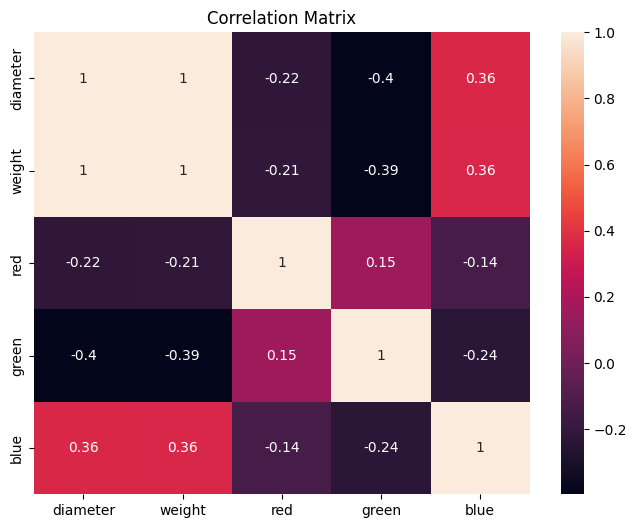

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('name', axis=1).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [18]:
le = LabelEncoder()
df['name'] = le.fit_transform(df['name'])

X = df.drop('name', axis=1)
y = df['name']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [22]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [23]:
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [24]:
print("Decision Tree :", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes   :", accuracy_score(y_test, y_pred_nb))
print("SVM           :", accuracy_score(y_test, y_pred_svm))

Decision Tree : 0.9435
Naive Bayes   : 0.92
SVM           : 0.937


In [25]:
print("\n=== SVM REPORT ===")
print(classification_report(y_test, y_pred_svm))


=== SVM REPORT ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       988
           1       0.95      0.92      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [26]:
print("\n=== SVM REPORT ===")
print(classification_report(y_test, y_pred_svm))


=== SVM REPORT ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       988
           1       0.95      0.92      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



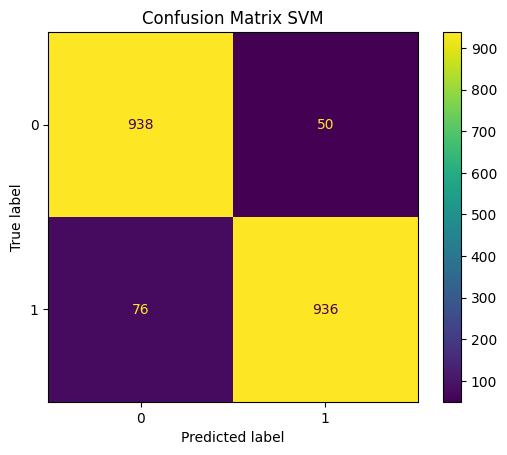

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("Confusion Matrix SVM")
plt.show()

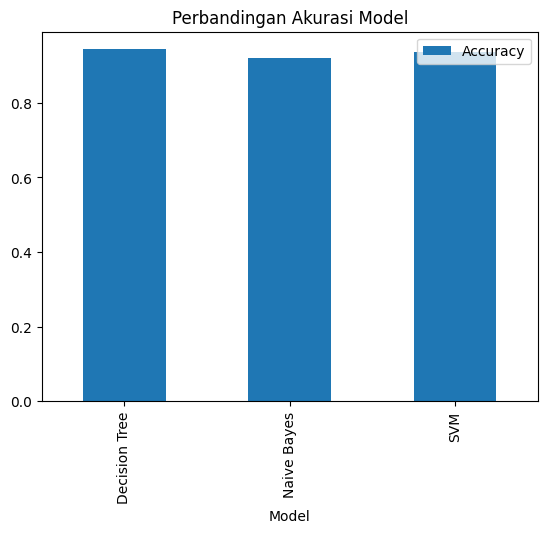

In [28]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results.plot(x='Model', y='Accuracy', kind='bar')
plt.title("Perbandingan Akurasi Model")
plt.show()